In [1]:
!pip install requests beautifulsoup4 PySastrawi nltk scikit-learn pandas matplotlib seaborn tqdm -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil diinstall!')

✅ Semua library berhasil diinstall!


---
## Data Crawling
Mengambil data berita dari **Detik.com** secara otomatis menggunakan `requests` dan `BeautifulSoup`.  
Target: minimal **100 artikel per kategori** → total **≥ 300 artikel**.

**Output:** `berita.csv` dengan kolom: `kategori`, `judul`, `link`, `tgl_publikasi`, `konten_berita`



In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re

# Konfigurasi 
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    )
}

SUMBER = {
    'Olahraga' : ['https://sport.detik.com/sepakbola',
                  'https://sport.detik.com/basket',
                  'https://sport.detik.com/raket'],
    'Ekonomi'  : ['https://finance.detik.com/berita-ekonomi-bisnis',
                  'https://finance.detik.com/moneter',
                  'https://finance.detik.com/industri'],
    'Hiburan'  : ['https://hot.detik.com/celebs',
                  'https://hot.detik.com/movie',
                  'https://hot.detik.com/music'],
}

TARGET_PER_KATEGORI = 110
print('✅ Konfigurasi siap.')

✅ Konfigurasi siap.


In [3]:
def ambil_link_artikel(url_daftar, kategori):
    hasil = []
    try:
        resp = requests.get(url_daftar, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')

        articles = soup.select('article.list-content__item')
        print(f'    [DEBUG] {url_daftar} -> {len(articles)} artikel')

        for art in articles:
            h_tag = art.find(['h2', 'h3'])
            a_tag = (h_tag.find('a', href=True) if h_tag else None) or art.find('a', href=True)
            if a_tag and h_tag:
                hasil.append({
                    'kategori': kategori,
                    'judul'   : h_tag.get_text(strip=True),
                    'link'    : a_tag['href'],
                })
    except Exception as e:
        print(f'  [WARN] {url_daftar}: {e}')
    return hasil


def ekstrak_konten(url):
    try:
        resp = requests.get(url, headers=HEADERS, timeout=12)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')

        tgl = ''
        tgl_tag = soup.find('div', class_='detail__date') or soup.find('span', class_='date')
        if tgl_tag:
            tgl = tgl_tag.get_text(strip=True)

        konten_div = soup.find('div', class_='detail__body-text') or \
                     soup.find('div', attrs={'itemprop': 'articleBody'})
        konten = ''
        if konten_div:
            paragraf = konten_div.find_all('p')
            konten = ' '.join(p.get_text(strip=True) for p in paragraf if p.get_text(strip=True))
        return tgl, konten
    except Exception as e:
        print(f'  [WARN] {url}: {e}')
        return '', ''

print('✅ Fungsi crawling siap.')

✅ Fungsi crawling siap.


In [4]:
# JALANKAN CRAWLING 

semua_data = []

for kategori, list_url in SUMBER.items():
    print(f'\n{"="*55}')
    print(f'  Crawling: {kategori.upper()}')
    print(f'{"="*55}')

    kandidat = []
    for url_listing in list_url:
        kandidat.extend(ambil_link_artikel(url_listing, kategori))
        time.sleep(random.uniform(1.0, 2.0))

    unik = list({item['link']: item for item in kandidat}.values())
    terkumpul = 0

    for item in unik:
        if terkumpul >= TARGET_PER_KATEGORI:
            break
        tgl, konten = ekstrak_konten(item['link'])
        if len(konten) < 100:
            continue
        semua_data.append({
            'kategori'    : item['kategori'],
            'judul'       : item['judul'],
            'link'        : item['link'],
            'tgl_publikasi': tgl,
            'konten_berita': konten,
        })
        terkumpul += 1
        print(f'  [{terkumpul}/{TARGET_PER_KATEGORI}] {item["judul"][:65]}...')
        time.sleep(random.uniform(0.8, 1.5))

    print(f'  => Terkumpul: {terkumpul} artikel')

df_raw = pd.DataFrame(semua_data, columns=['kategori','judul','link','tgl_publikasi','konten_berita'])
df_raw.to_csv('berita.csv', index=False, encoding='utf-8-sig')

print(f'\n✅ CRAWLING SELESAI — Total: {len(df_raw)} artikel')


  Crawling: OLAHRAGA
    [DEBUG] https://sport.detik.com/sepakbola -> 65 artikel
    [DEBUG] https://sport.detik.com/basket -> 70 artikel
    [DEBUG] https://sport.detik.com/raket -> 70 artikel
  [1/110] 5 Negara yang Sudah Tersingkir di Piala Dunia 2026...
  [2/110] Sindir VAR Untungkan Inggris, Queiroz: Wasit Video Lagi Ngopi?...
  [3/110] Top Skor Piala Dunia 2026: Messi Memimpin, Ronaldo Mulai Menggebr...
  [4/110] Piala Dunia 2026: 7 Negara Sudah Lolos ke 32 Besar, Kolombia Terb...
  [5/110] Ronaldo Bikin Gol, Ronaldo Catat Rekor Piala Dunia!...
  [6/110] Afrika Selatan Vs Korea Selatan 0-0 di Babak Pertama...
  [7/110] Bellingham Tutup Mulut, kok Gak Dapat Kartu Merah?...
  [8/110] Republik Ceko Vs Meksiko Tanpa Gol di Babak Pertama...
  [9/110] Video: Kesiapan Mental Jepang Jelang Pertandingan Lawan Swedia...
  [10/110] Video Brasil Hajar Skotlandia 3-0, Vinicius Brace...
  [11/110] Gila! Lionel Messi Masih Ingin Tampil di Piala Dunia 2030?...
  [12/110] Klasemen Akhir Grup C P

In [5]:
df_raw = pd.read_csv('berita.csv', encoding='utf-8-sig')

print('='*60)
print('LAMPIRAN 1 — Preview Dataset berita.csv')
print('='*60)
print(f'Total baris : {len(df_raw)}')
print(f'Kolom       : {list(df_raw.columns)}')
print()
print('Distribusi per Kategori:')
print(df_raw['kategori'].value_counts().to_string())
print()

display(df_raw[['kategori','judul','tgl_publikasi']].head(10))

LAMPIRAN 1 — Preview Dataset berita.csv
Total baris : 330
Kolom       : ['kategori', 'judul', 'link', 'tgl_publikasi', 'konten_berita']

Distribusi per Kategori:
kategori
Olahraga    110
Ekonomi     110
Hiburan     110



,kategori,judul,tgl_publikasi
0,Olahraga,5 Negara yang Sudah Tersingkir di Piala Dunia ...,NaN
1,Olahraga,"Sindir VAR Untungkan Inggris, Queiroz: Wasit V...",NaN
2,Olahraga,"Top Skor Piala Dunia 2026: Messi Memimpin, Ron...",NaN
3,Olahraga,Piala Dunia 2026: 7 Negara Sudah Lolos ke 32 B...,NaN
4,Olahraga,"Ronaldo Bikin Gol, Ronaldo Catat Rekor Piala D...",NaN
5,Olahraga,Afrika Selatan Vs Korea Selatan 0-0 di Babak P...,NaN
6,Olahraga,"Bellingham Tutup Mulut, kok Gak Dapat Kartu Me...",NaN
7,Olahraga,Republik Ceko Vs Meksiko Tanpa Gol di Babak Pe...,NaN
8,Olahraga,Video: Kesiapan Mental Jepang Jelang Pertandin...,"4,160 Views | \n ..."
9,Olahraga,"Video Brasil Hajar Skotlandia 3-0, Vinicius Brace","5,525 Views | \n ..."


---
##  Prapemrosesan Teks
Tahapan: **Cleaning → Case Folding → Tokenisasi → Stopword Removal → Stemming**

**Output:** kolom baru `teks_bersih` di `berita_bersih.csv`

In [6]:
import re
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer      = StemmerFactory().create_stemmer()
stopword_list = set(StopWordRemoverFactory().get_stop_words())

print(f'✅ Sastrawi siap | Jumlah stopword: {len(stopword_list)}')
print(f'Contoh stopword: {list(stopword_list)[:10]}')

✅ Sastrawi siap | Jumlah stopword: 809
Contoh stopword: ['tampak', 'adapun', 'apakah', 'mempersoalkan', 'pastilah', 'asalkan', 'dimulai', 'begitu', 'berlalu', 'pula']


In [7]:
def cleaning(teks):
    teks = re.sub(r'https?://\S+|www\.\S+', ' ', teks)   # hapus URL
    teks = re.sub(r'[@#]\S+', ' ', teks)                  # hapus mention/hashtag
    teks = re.sub(r'\d+', ' ', teks)                       # hapus angka
    teks = re.sub(r'[^a-zA-Z\s]', ' ', teks)              # hapus tanda baca
    teks = re.sub(r'\s+', ' ', teks).strip()               # hapus spasi berlebih
    return teks

def case_folding(teks):
    """Ubah ke huruf kecil."""
    return teks.lower()

def tokenisasi(teks):
    """Pisah teks menjadi token."""
    return word_tokenize(teks)

def hapus_stopword(tokens):
    """Hapus stopword bahasa Indonesia."""
    return [t for t in tokens if t not in stopword_list and len(t) > 1]

def lakukan_stemming(tokens):
    """Reduksi kata ke bentuk dasar (Sastrawi)."""
    return [stemmer.stem(t) for t in tokens]

def preprocess(teks):
    """Pipeline lengkap prapemrosesan."""
    if not isinstance(teks, str) or teks.strip() == '':
        return ''
    teks    = cleaning(teks)
    teks    = case_folding(teks)
    tokens  = tokenisasi(teks)
    tokens  = hapus_stopword(tokens)
    tokens  = lakukan_stemming(tokens)
    return ' '.join(tokens)

print('✅ Fungsi preprocessing siap.')

✅ Fungsi preprocessing siap.


In [8]:
contoh = 'Timnas Indonesia berhasil mengalahkan Malaysia dengan skor 3-1 pada pertandingan final!'
tahap1 = cleaning(contoh)
tahap2 = case_folding(tahap1)
tahap3 = tokenisasi(tahap2)
tahap4 = hapus_stopword(tahap3)
tahap5 = lakukan_stemming(tahap4)

print('='*65)
print('LAMPIRAN 2 — Demonstrasi Tahapan Prapemrosesan Teks')
print('='*65)
print(f'[0] TEKS ASLI     : {contoh}')
print(f'[1] CLEANING      : {tahap1}')
print(f'[2] CASE FOLDING  : {tahap2}')
print(f'[3] TOKENISASI    : {tahap3}')
print(f'[4] STOPWORD RM   : {tahap4}')
print(f'[5] STEMMING      : {tahap5}')

hasil_akhir = ' '.join(tahap5)
print(f'[6] HASIL AKHIR   : {hasil_akhir}')
print('='*65)

LAMPIRAN 2 — Demonstrasi Tahapan Prapemrosesan Teks
[0] TEKS ASLI     : Timnas Indonesia berhasil mengalahkan Malaysia dengan skor 3-1 pada pertandingan final!
[1] CLEANING      : Timnas Indonesia berhasil mengalahkan Malaysia dengan skor pada pertandingan final
[2] CASE FOLDING  : timnas indonesia berhasil mengalahkan malaysia dengan skor pada pertandingan final
[3] TOKENISASI    : ['timnas', 'indonesia', 'berhasil', 'mengalahkan', 'malaysia', 'dengan', 'skor', 'pada', 'pertandingan', 'final']
[4] STOPWORD RM   : ['timnas', 'indonesia', 'berhasil', 'mengalahkan', 'malaysia', 'skor', 'pertandingan', 'final']
[5] STEMMING      : ['timnas', 'indonesia', 'hasil', 'kalah', 'malaysia', 'skor', 'tanding', 'final']
[6] HASIL AKHIR   : timnas indonesia hasil kalah malaysia skor tanding final


#  JALANKAN PREPROCESSING 

In [9]:
from tqdm import tqdm
tqdm.pandas()

df = pd.read_csv('berita.csv', encoding='utf-8-sig')
df.dropna(subset=['konten_berita'], inplace=True)
df = df[df['konten_berita'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f'Data awal: {len(df)} baris')
df['teks_bersih'] = df['konten_berita'].progress_apply(preprocess)

df = df[df['teks_bersih'].str.split().str.len() >= 10]
df.reset_index(drop=True, inplace=True)

df.to_csv('berita_bersih.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ PREPROCESSING SELESAI — Data bersih: {len(df)} baris')
print(df[['kategori','teks_bersih']].head())

Data awal: 330 baris


100%|██████████| 330/330 [00:01<00:00, 250.06it/s]


✅ PREPROCESSING SELESAI — Data bersih: 330 baris
   kategori                                        teks_bersih
0  Olahraga  piala dunia sisa laga fase grup tim singkir pi...
1  Olahraga  latih ghana carlos queiroz lontar kritik pedas...
2  Olahraga  saing rebut sepatu emas piala dunia panas lion...
3  Olahraga  kolombiamengamankan tiket besarpiala dunia kal...
4  Olahraga  cristiano ronaldomencetak gol kalaportugalmeli...


#  Perbandingan sebelum & sesudah preprocessing 

In [10]:
df = pd.read_csv('berita_bersih.csv', encoding='utf-8-sig')

print('='*65)
print('LAMPIRAN 3 — Contoh Hasil Prapemrosesan (3 Sampel)')
print('='*65)
for i, row in df.head(3).iterrows():
    print(f'\n--- Sampel {i+1} | Kategori: {row["kategori"]} ---')
    print(f'SEBELUM : {str(row["konten_berita"])[:150]}...')
    print(f'SESUDAH : {str(row["teks_bersih"])[:150]}...')

print(f'\n\nStatistik:')
df['panjang_asli']   = df['konten_berita'].str.split().str.len()
df['panjang_bersih'] = df['teks_bersih'].str.split().str.len()
print(f'Rata-rata token SEBELUM preprocessing : {df["panjang_asli"].mean():.0f} kata')
print(f'Rata-rata token SESUDAH preprocessing : {df["panjang_bersih"].mean():.0f} kata')
print(f'Reduksi rata-rata                     : {(1 - df["panjang_bersih"].mean()/df["panjang_asli"].mean())*100:.1f}%')

LAMPIRAN 3 — Contoh Hasil Prapemrosesan (3 Sampel)

--- Sampel 1 | Kategori: Olahraga ---
SEBELUM : Piala Dunia 2026sisakan laga terakhir di fase grup. Sudah ada lima tim yang dipastikan tersingkir! Piala Dunia 2026akan mainkanmatchdayketiga pada Kam...
SESUDAH : piala dunia sisa laga fase grup tim singkir piala dunia mainkanmatchdayketiga kamis minggu grup main laga jam tanding scroll to continue with content ...

--- Sampel 2 | Kategori: Olahraga ---
SEBELUM : Pelatih Ghana Carlos Queiroz melontarkan kritik pedas kepada VAR setelah timnya ditahan Inggris 0-0 pada laga Grup L Piala Dunia 2026. Queiroz merasa ...
SESUDAH : latih ghana carlos queiroz lontar kritik pedas var tim tahan inggris laga grup piala dunia queiroz ghana rugi penalti tanding ghana tampil disiplin ha...

--- Sampel 3 | Kategori: Olahraga ---
SEBELUM : Persaingan perebutan Sepatu Emas Piala Dunia 2026 semakin panas. Lionel Messi masih memimpin daftar top skor sementara dengan lima gol dan Cristiano R...
SESUDAH : sa

---
## BAGIAN 3: Ekstraksi Fitur TF-IDF
Mengubah teks bersih menjadi representasi numerik (matriks angka) menggunakan **TF-IDF**.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

df = pd.read_csv('berita_bersih.csv', encoding='utf-8-sig')
df.dropna(subset=['teks_bersih','kategori'], inplace=True)
df = df[df['teks_bersih'].str.strip() != '']

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),    # unigram + bigram
    sublinear_tf=True,     # log(TF) agar tidak bias teks panjang
    min_df=2,
)

X = tfidf.fit_transform(df['teks_bersih'])
y = df['kategori']

le = LabelEncoder()
y_enc = le.fit_transform(y)
label_names = le.classes_


print('='*60)
print('LAMPIRAN 4 — Informasi Matriks TF-IDF')
print('='*60)
print(f'Dimensi matriks         : {X.shape[0]} dokumen × {X.shape[1]} fitur')
print(f'Total elemen matriks    : {X.shape[0] * X.shape[1]:,}')
density = X.nnz / (X.shape[0] * X.shape[1])
print(f'Jumlah elemen non-nol   : {X.nnz:,}')
print(f'Tingkat kepadatan       : {density*100:.3f}% (sparse matrix)')
print(f'Label kelas             : {list(label_names)}')
print()
print('20 Fitur/Kata dengan Bobot TF-IDF Tertinggi:')
fitur_names = tfidf.get_feature_names_out()
mean_tfidf  = X.mean(axis=0).A1
top20_idx   = mean_tfidf.argsort()[::-1][:20]
for rank, idx in enumerate(top20_idx, 1):
    print(f'  {rank:2d}. {fitur_names[idx]:<25} bobot: {mean_tfidf[idx]:.5f}')

LAMPIRAN 4 — Informasi Matriks TF-IDF
Dimensi matriks         : 330 dokumen × 5000 fitur
Total elemen matriks    : 1,650,000
Jumlah elemen non-nol   : 41,447
Tingkat kepadatan       : 2.512% (sparse matrix)
Label kelas             : ['Ekonomi', 'Hiburan', 'Olahraga']

20 Fitur/Kata dengan Bobot TF-IDF Tertinggi:
   1. indonesia                 bobot: 0.02233
   2. main                      bobot: 0.02131
   3. anak                      bobot: 0.02092
   4. tahun                     bobot: 0.02058
   5. dunia                     bobot: 0.01985
   6. tim                       bobot: 0.01966
   7. film                      bobot: 0.01960
   8. jalan                     bobot: 0.01848
   9. hasil                     bobot: 0.01768
  10. to                        bobot: 0.01730
  11. content                   bobot: 0.01695
  12. with                      bobot: 0.01691
  13. continue with             bobot: 0.01681
  14. scroll                    bobot: 0.01681
  15. scroll to             

In [12]:
#  Split data 80:20 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

print('='*50)
print('Pembagian Data Latih dan Uji (80:20)')
print('='*50)
print(f'Data latih : {X_train.shape[0]} sampel ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'Data uji   : {X_test.shape[0]}  sampel ({X_test.shape[0]/X.shape[0]*100:.0f}%)')

Pembagian Data Latih dan Uji (80:20)
Data latih : 264 sampel (80%)
Data uji   : 66  sampel (20%)


---
##  Pemodelan & Evaluasi
Melatih dan mengevaluasi 4 algoritma:
1. **Multinomial Naive Bayes**
2. **Support Vector Machine** (kernel linear)
3. **Random Forest**
4. **Logistic Regression**

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

MODELS = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'SVM (Linear)'       : LinearSVC(C=1.0, max_iter=5000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42),
}

hasil_evaluasi = []
prediksi_per_model = {}

for nama, model in MODELS.items():
    print(f'  ▸ Melatih {nama}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    prediksi_per_model[nama] = y_pred
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    hasil_evaluasi.append({
        'Model'       : nama,
        'Akurasi (%)' : round(acc  * 100, 2),
        'Presisi (%)' : round(prec * 100, 2),
        'Recall (%)'  : round(rec  * 100, 2),
        'F1-Score (%)': round(f1   * 100, 2),
    })
    print(f'    ✓ Akurasi: {acc*100:.2f}%  |  F1: {f1*100:.2f}%')

print('\n✅ Semua model selesai dilatih!')

  ▸ Melatih Naive Bayes...
    ✓ Akurasi: 100.00%  |  F1: 100.00%
  ▸ Melatih SVM (Linear)...
    ✓ Akurasi: 100.00%  |  F1: 100.00%
  ▸ Melatih Random Forest...
    ✓ Akurasi: 98.48%  |  F1: 98.48%
  ▸ Melatih Logistic Regression...
    ✓ Akurasi: 100.00%  |  F1: 100.00%

✅ Semua model selesai dilatih!


#  Tabel Perbandingan Model 


LAMPIRAN 5 — Tabel Perbandingan Performa Keempat Model


,Model,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
1,Naive Bayes,100.00,100.00,100.00,100.00
2,SVM (Linear),100.00,100.00,100.00,100.00
3,Logistic Regression,100.00,100.00,100.00,100.00
4,Random Forest,98.48,98.55,98.48,98.48



🏆 Model terbaik : Naive Bayes
   Akurasi       : 100.00%
   F1-Score      : 100.00%


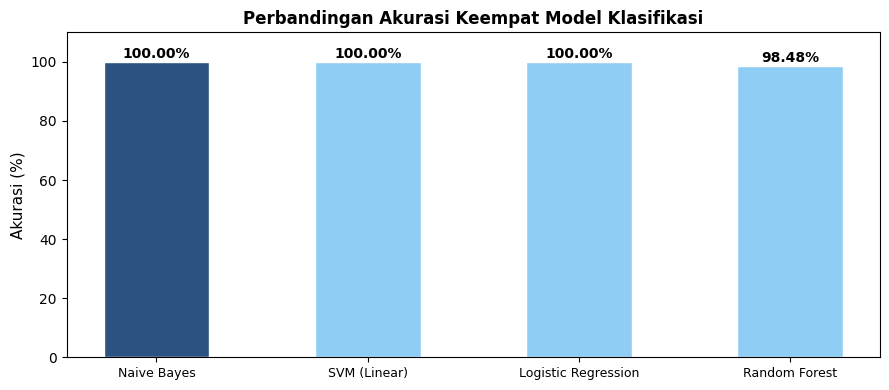


Grafik disimpan: grafik_akurasi.png


In [15]:
import matplotlib.pyplot as plt

df_eval = pd.DataFrame(hasil_evaluasi)
df_eval = df_eval.sort_values('Akurasi (%)', ascending=False).reset_index(drop=True)
df_eval.index += 1

print('='*65)
print('LAMPIRAN 5 — Tabel Perbandingan Performa Keempat Model')
print('='*65)
display(df_eval)

best = df_eval.iloc[0]
print(f'\n🏆 Model terbaik : {best["Model"]}')
print(f'   Akurasi       : {best["Akurasi (%)"]:.2f}%')
print(f'   F1-Score      : {best["F1-Score (%)"]:.2f}%')

df_eval.to_csv('hasil_evaluasi.csv', encoding='utf-8-sig')

# ── Bar chart perbandingan akurasi ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2C5282' if i == 0 else '#90CDF4' for i in range(len(df_eval))]
bars = ax.bar(df_eval['Model'], df_eval['Akurasi (%)'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, df_eval['Akurasi (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Akurasi (%)', fontsize=11)
ax.set_title('Perbandingan Akurasi Keempat Model Klasifikasi', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('grafik_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGrafik disimpan: grafik_akurasi.png')

# Classification Report per Kelas 

In [16]:
print('='*65)
print('LAMPIRAN 6 — Classification Report Per Kelas (Per Kategori)')
print('='*65)
for nama, y_pred in prediksi_per_model.items():
    print(f'\n──── {nama} ────')
    print(classification_report(y_test, y_pred,
                                target_names=label_names,
                                zero_division=0))

LAMPIRAN 6 — Classification Report Per Kelas (Per Kategori)

──── Naive Bayes ────
              precision    recall  f1-score   support

     Ekonomi       1.00      1.00      1.00        22
     Hiburan       1.00      1.00      1.00        22
    Olahraga       1.00      1.00      1.00        22

    accuracy                           1.00        66
   macro avg       1.00      1.00      1.00        66
weighted avg       1.00      1.00      1.00        66


──── SVM (Linear) ────
              precision    recall  f1-score   support

     Ekonomi       1.00      1.00      1.00        22
     Hiburan       1.00      1.00      1.00        22
    Olahraga       1.00      1.00      1.00        22

    accuracy                           1.00        66
   macro avg       1.00      1.00      1.00        66
weighted avg       1.00      1.00      1.00        66


──── Random Forest ────
              precision    recall  f1-score   support

     Ekonomi       1.00      0.95      0.98        

#  Confusion Matrix Gabungan 


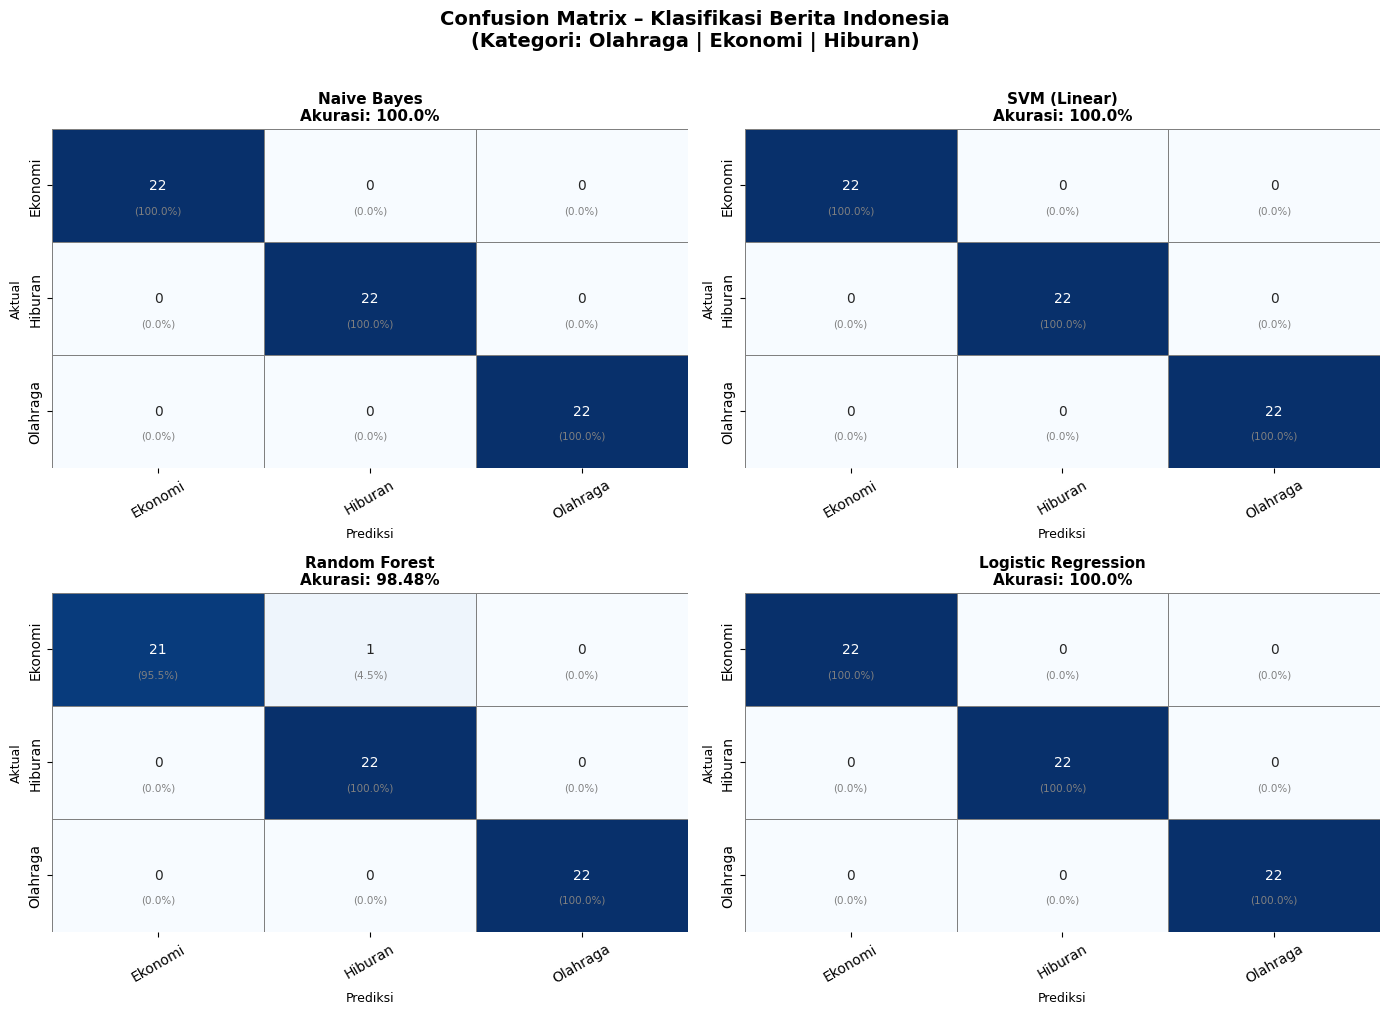


✅ Gambar disimpan: confusion_matrix_all.png


In [21]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle(
    'Confusion Matrix – Klasifikasi Berita Indonesia\n'
    '(Kategori: Olahraga | Ekonomi | Hiburan)',
    fontsize=14, fontweight='bold', y=1.01
)

for idx, (nama, y_pred) in enumerate(prediksi_per_model.items()):
    cm  = confusion_matrix(y_test, y_pred)
    ax  = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.5, linecolor='gray', cbar=False)

    # Tambah persentase
    cm_pct = (cm / cm.sum(axis=1, keepdims=True) * 100).round(1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j+0.5, i+0.72, f'({cm_pct[i,j]}%)',
                    ha='center', va='center', fontsize=7.5, color='gray')

    acc_val = next(r['Akurasi (%)'] for r in hasil_evaluasi if r['Model'] == nama)
    ax.set_title(f'{nama}\nAkurasi: {acc_val}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Gambar disimpan: confusion_matrix_all.png')

# Confusion Matrix Individual

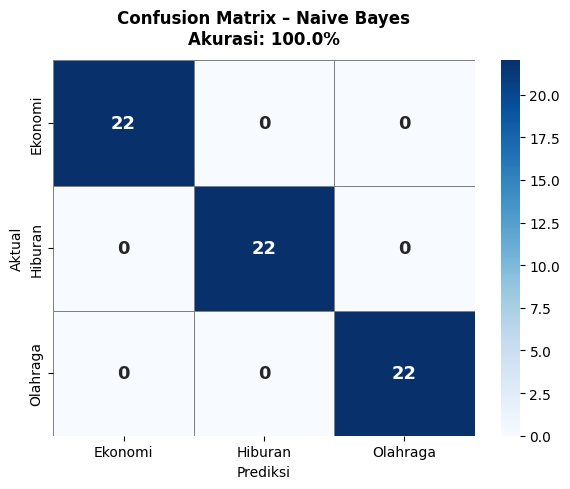

  ✓ Disimpan: cm_naive_bayes.png


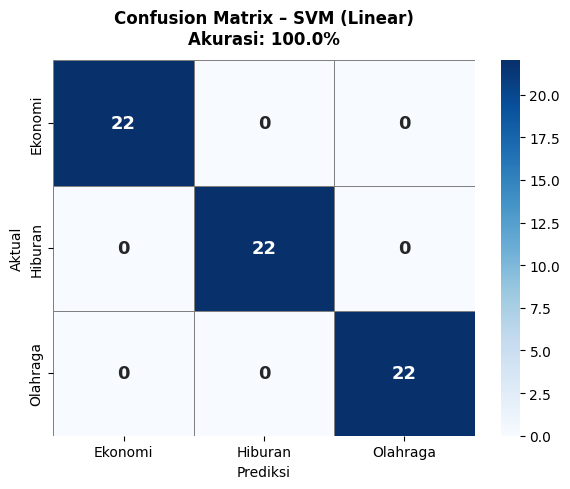

  ✓ Disimpan: cm_svm_linear.png


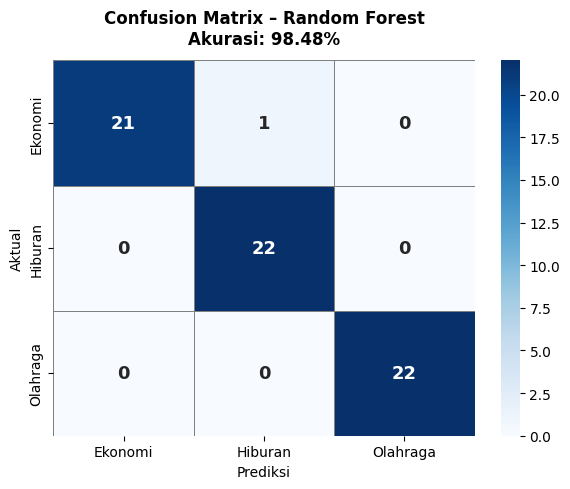

  ✓ Disimpan: cm_random_forest.png


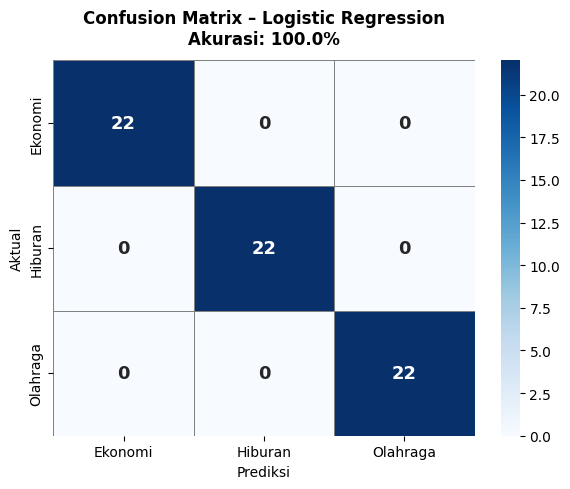

  ✓ Disimpan: cm_logistic_regression.png


In [18]:
for nama, y_pred in prediksi_per_model.items():
    cm = confusion_matrix(y_test, y_pred)
    fig_s, ax_s = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax_s, linewidths=0.5, linecolor='gray',
                annot_kws={'size': 13, 'weight': 'bold'})
    acc_val = next(r['Akurasi (%)'] for r in hasil_evaluasi if r['Model'] == nama)
    ax_s.set_title(f'Confusion Matrix – {nama}\nAkurasi: {acc_val}%',
                   fontsize=12, fontweight='bold', pad=12)
    ax_s.set_xlabel('Prediksi', fontsize=10)
    ax_s.set_ylabel('Aktual', fontsize=10)
    plt.tight_layout()
    fname = f'cm_{nama.lower().replace(" ","_").replace("(","").replace(")","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Disimpan: {fname}')

# ── RINGKASAN AKHIR ──

In [20]:
print('='*65)
print('RINGKASAN PROYEK TEXT MINING')
print('='*65)
print(f'Dataset         : {len(df)} artikel berita')
print(f'Kategori        : {list(label_names)}')
print(f'Data latih      : {X_train.shape[0]} sampel (80%)')
print(f'Data uji        : {X_test.shape[0]} sampel (20%)')
print(f'Fitur TF-IDF    : {X.shape[1]} fitur (unigram + bigram)')
print()
print('HASIL EVALUASI MODEL (diurutkan dari terbaik):')
display(df_eval)
print()


RINGKASAN PROYEK TEXT MINING
Dataset         : 330 artikel berita
Kategori        : ['Ekonomi', 'Hiburan', 'Olahraga']
Data latih      : 264 sampel (80%)
Data uji        : 66 sampel (20%)
Fitur TF-IDF    : 5000 fitur (unigram + bigram)

HASIL EVALUASI MODEL (diurutkan dari terbaik):


,Model,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
1,Naive Bayes,100.00,100.00,100.00,100.00
2,SVM (Linear),100.00,100.00,100.00,100.00
3,Logistic Regression,100.00,100.00,100.00,100.00
4,Random Forest,98.48,98.55,98.48,98.48
